In [17]:
from matplotlib.pyplot import cm
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import sys, os, git
import warnings
warnings.filterwarnings("ignore")

In [18]:
current_path = os.getcwd()
git_repo = git.Repo(current_path, search_parent_directories=True)
git_path = git_repo.git.rev_parse("--show-toplevel")
path_figures = current_path[len(git_path):] + '/'
path_in_folder = current_path[len(git_path)+1:]

In [19]:
sys.path.append(git_path + "/.submodules/pyplot-perso")
from plttools import PltTools

In [20]:
data_path = git_path + "/.submodules/dataset-peg-water-mixture/analysis/"
cmap_cool = cm.cool
cmap_cyan_to_green_blue = LinearSegmentedColormap.from_list(
    "cyan_to_green_blue", ["#00FFFF", "#00FA9A", "#0f55eb"])

  Pixels: width = 482.7 x height = 477.6
  Aspect ratio: 1.0106
  Pixels: width = 482.7 x height = 477.6
  Aspect ratio: 1.0106


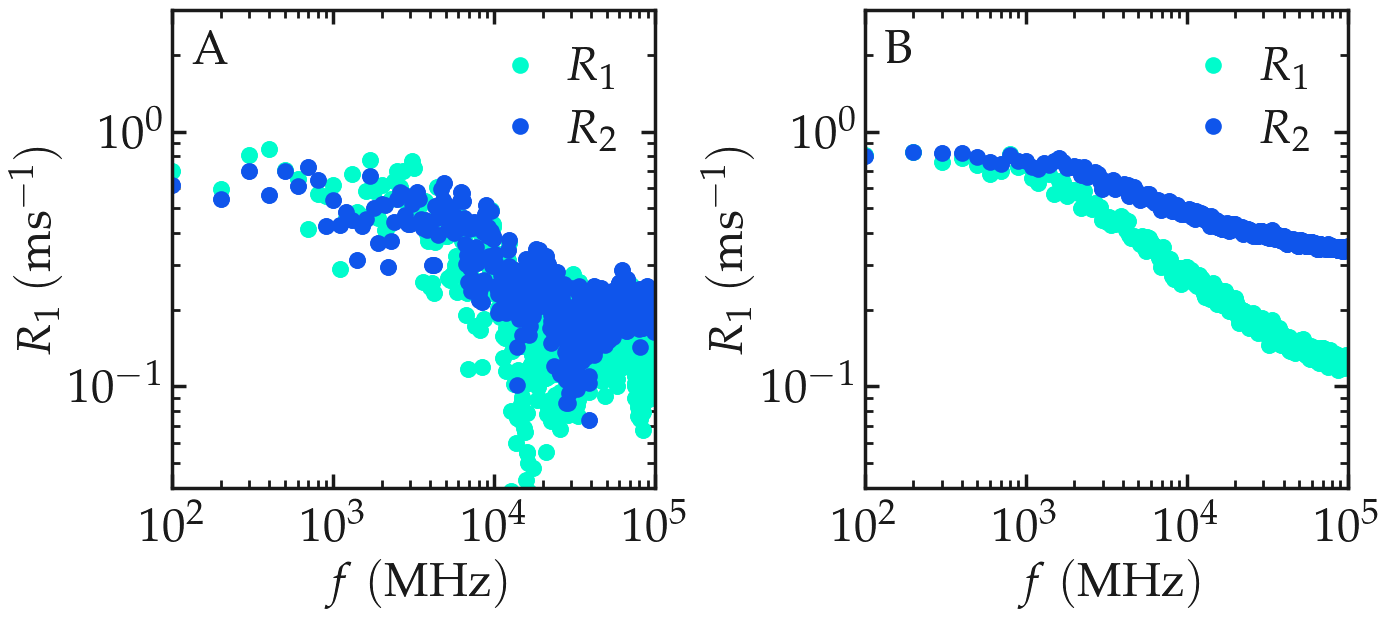

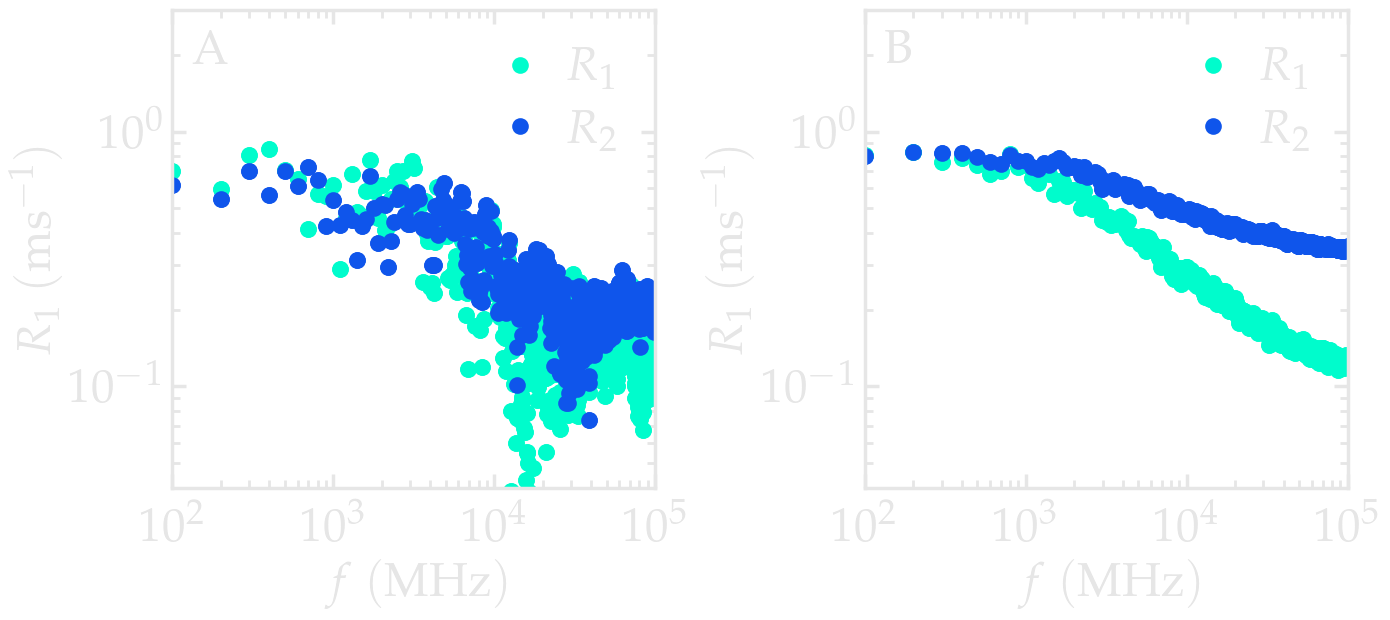

In [21]:
filename = "nmr-total"

for dark_mode in [False, True]:
        
    colors = cmap_cyan_to_green_blue(np.linspace(0, 1, 5))

    myplt = PltTools()
    myplt.prepare_figure(fig_size = (14,6.3), dark_mode = dark_mode,
                         transparency = True, use_serif=True, n_colone = 2)
    
    # Panel 1
    myplt.add_panel()
    ni = 20
    data = np.load(data_path + f"nmr_all/result{ni}.npy", allow_pickle=True).item()
    myplt.add_plot(x = data["f"], y = data["R1"], type = "loglog", linewidth_data = 3,
                marker = "o", data_color = colors[1][:3], markersize = 12,
                data_label = f'$R_1$')
    myplt.add_plot(x = data["f"], y = data["R2"], type = "loglog", linewidth_data = 3,
                marker = "o", data_color = colors[-1][:3], markersize = 12,
                data_label = f'$R_2$')
    myplt.complete_panel(ylabel = r'$R_1~(\mathrm{ms}^{-1})$', xlabel = r'$f~(\mathrm{MHz})$',
                            xpad = 15, legend=True, handlelength_legend=1)
    myplt.set_boundaries(x_boundaries=(1e2, 1e5), y_boundaries=(4e-2, 3))

    # Panel 2
    myplt.add_panel()
    ni = 1280
    data = np.load(data_path + f"nmr_all/result{ni}.npy", allow_pickle=True).item()
    myplt.add_plot(x = data["f"], y = data["R1"], type = "loglog", linewidth_data = 3,
                marker = "o", data_color = colors[1][:3], markersize = 12,
                data_label = f'$R_1$')
    myplt.add_plot(x = data["f"], y = data["R2"], type = "loglog", linewidth_data = 3,
                marker = "o", data_color = colors[-1][:3], markersize = 12,
                data_label = f'$R_2$')
    myplt.complete_panel(ylabel = r'$R_1~(\mathrm{ms}^{-1})$', xlabel = r'$f~(\mathrm{MHz})$',
                            xpad = 15, legend=True, handlelength_legend=1)
    myplt.set_boundaries(x_boundaries=(1e2, 1e5), y_boundaries=(4e-2, 3))

    myplt.add_subplotlabels(type_label_panel = "A")
    myplt.save_figure(filename = filename, saving_path = git_path+path_figures)